# Import Librarie

In [9]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("default")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [10]:
DATA_PATH = Path("../data/processed/master")

sales_master = pd.read_csv(
    DATA_PATH / "sales_master.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

print(f"Rows    : {sales_master.shape[0]:,}")
print(f"Columns : {sales_master.shape[1]}")

Rows    : 113,425
Columns : 46


In [11]:
sales_master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_quarter,purchase_day,purchase_hour,purchase_weekday,is_weekend,approval_time_hours,delivery_time_days,shipping_time_days,estimated_delivery_days,delivery_delay_days,is_delayed,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,4,2,10,Monday,False,0.18,8.0,6.0,15,-8.0,False,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,38.71,1.0,voucher,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,3,24,20,Tuesday,False,30.71,13.0,12.0,19,-6.0,False,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,141.46,1.0,boleto,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,3,8,8,Wednesday,False,0.28,9.0,9.0,26,-18.0,False,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,179.12,3.0,credit_card,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,4,18,19,Saturday,True,0.30,13.0,9.0,26,-13.0,False,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,72.20,1.0,credit_card,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,1,13,21,Tuesday,False,1.03,2.0,1.0,12,-10.0,False,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,28.62,1.0,credit_card,5.0


In [12]:
sales_master.sample(5, random_state=42)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_quarter,purchase_day,purchase_hour,purchase_weekday,is_weekend,approval_time_hours,delivery_time_days,shipping_time_days,estimated_delivery_days,delivery_delay_days,is_delayed,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,review_score
72065,04c3bddd55df58e83123e3b174855489,cf45e9bc7544ba97a0db03c7c7bf63c9,delivered,2018-01-26 21:34:07,2018-01-26 21:58:36,2018-02-14 20:53:13,2018-03-01 19:07:36,2018-03-02,2018,1,1,26,21,Friday,False,0.41,33.0,14.0,34,-1.0,False,c4ebedb09beb89cc0314c5c0c33f8053,9961,diadema,SP,1.0,f4f4debbcfcafe6858d1e37a1f6e436e,7c67e1448b00f6e969d365cea6b010ab,2018-02-09 21:58:36,139.94,35.14,moveis_escritorio,33.0,1190.0,1.0,13867.0,101.0,8.0,57.0,8577.0,itaquaquecetuba,SP,175.08,4.0,credit_card,1.0
651,118045506e1c1dda060171af43fe11b4,638c6674418fc58283a73c078bcb076f,delivered,2018-03-08 19:06:05,2018-03-09 19:08:26,2018-03-13 21:24:28,2018-04-11 12:53:50,2018-04-04,2018,3,1,8,19,Thursday,False,24.04,33.0,28.0,26,7.0,True,5a494c648fde2d1ec4eb614274ea7159,44900,irece,BA,2.0,2c4930c4b284c7b99db2a4c52071a45e,2a261b5b644fa05f4f2700eb93544f2c,2018-03-15 19:08:26,45.00,27.08,moveis_decoracao,55.0,264.0,1.0,9050.0,35.0,30.0,35.0,13660.0,porto ferreira,SP,360.40,1.0,credit_card,1.0
69732,a29c25c2c9c3100daf48a25880312c23,00f394e6fc446865ac4097b6db69ef4a,delivered,2018-08-01 02:02:28,2018-08-01 02:15:06,2018-08-01 15:35:00,2018-08-08 18:58:43,2018-08-27,2018,8,3,1,2,Wednesday,False,0.21,7.0,7.0,25,-19.0,False,ab1d731d10eee8bf32306f5452eb770f,26574,mesquita,RJ,3.0,9ac1378f05cd222b3fb34a3cccc626c7,f46490624488d3ff7ce78613913a7711,2018-08-07 02:15:06,39.90,18.08,beleza_saude,31.0,1406.0,1.0,1075.0,21.0,19.0,19.0,7194.0,guarulhos,SP,289.90,5.0,credit_card,1.0
44231,8421e7437b4c46dcf0e4895873ed8726,491dfc36c496e8880a5621b8ce98a2b6,delivered,2018-01-10 23:58:35,2018-01-11 18:27:40,2018-01-12 20:29:14,2018-01-18 00:32:21,2018-02-05,2018,1,1,10,23,Wednesday,False,18.48,7.0,5.0,25,-18.0,False,a356e54a963f87caa2bbeae7c97d2f98,74356,goiania,GO,1.0,530fa1d000866012c51ce412598ef24c,1da3aeb70d7989d1e6d9b0e887f97c23,2018-01-17 18:27:40,12.99,14.10,fashion_bolsas_e_acessorios,49.0,267.0,1.0,200.0,16.0,10.0,12.0,4265.0,sao paulo,SP,27.09,1.0,boleto,5.0
107983,11ac39053e8c6e289d39a845c1a9c3b0,31f74614d63dae6a838d639204a889dc,delivered,2017-08-21 20:40:53,2017-08-21 20:55:22,2017-08-23 18:22:33,2017-09-06 22:39:43,2017-09-21,2017,8,3,21,20,Monday,False,0.24,16.0,14.0,30,-15.0,False,59f88b3d7efa3d6c729d73592ff6958b,52081,recife,PE,1.0,51d646c5c93e0f1de543528d0e24eadc,c35672b10ad50968f567ea3f4b91e877,2017-08-25 20:55:22,55.50,24.94,beleza_saude,46.0,1305.0,1.0,1400.0,27.0,10.0,17.0,26551.0,mesquita,RJ,80.44,4.0,credit_card,5.0


In [13]:
sales_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 46 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  str           
 1   customer_id                    113425 non-null  str           
 2   order_status                   113425 non-null  str           
 3   order_purchase_timestamp       113425 non-null  datetime64[us]
 4   order_approved_at              113264 non-null  datetime64[us]
 5   order_delivered_carrier_date   111457 non-null  datetime64[us]
 6   order_delivered_customer_date  110196 non-null  datetime64[us]
 7   order_estimated_delivery_date  113425 non-null  datetime64[us]
 8   purchase_year                  113425 non-null  int64         
 9   purchase_month                 113425 non-null  int64         
 10  purchase_quarter               113425 non-null  int64         
 11  purchase_da

In [14]:
sales_master.describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,113425,2017-12-31 12:25:41.686480,2016-09-04 21:15:19,2017-09-13 11:05:49,2018-01-19 10:37:45,2018-05-04 14:22:16,2018-10-17 17:30:18,NaN
order_approved_at,113264,2017-12-31 22:40:56.664121,2016-09-15 12:16:38,2017-09-13 20:25:10.500000,2018-01-19 16:59:52.500000,2018-05-04 18:31:38.500000,2018-09-03 17:40:06,NaN
order_delivered_carrier_date,111457,2018-01-05 02:17:27.942515,2016-10-08 10:34:01,2017-09-18 20:37:00,2018-01-24 18:44:33,2018-05-08 13:20:00,2018-09-11 19:48:28,NaN
order_delivered_customer_date,110196,2018-01-14 13:25:24.023938,2016-10-11 13:46:32,2017-09-26 20:09:44.500000,2018-02-02 20:57:23,2018-05-15 20:09:21.500000,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,113425,2018-01-24 08:22:34.875909,2016-09-30 00:00:00,2017-10-04 00:00:00,2018-02-15 00:00:00,2018-05-25 00:00:00,2018-11-12 00:00:00,NaN
purchase_year,113425.0,2017.540137,2016.0,2017.0,2018.0,2018.0,2018.0,0.505188
purchase_month,113425.0,6.032162,1.0,3.0,6.0,8.0,12.0,3.234963
purchase_quarter,113425.0,2.356174,1.0,1.0,2.0,3.0,4.0,1.063118
purchase_day,113425.0,15.553123,1.0,8.0,16.0,23.0,31.0,8.666099
purchase_hour,113425.0,14.746934,0.0,11.0,15.0,19.0,23.0,5.313318


In [15]:
duplicate_rows = sales_master.duplicated().sum()

print(f"Duplicate Rows : {duplicate_rows:,}")

Duplicate Rows : 0


In [23]:
categorical_features = sales_master.select_dtypes(
    include=["object","category","bool"]
).columns.tolist()

business_numeric = [
    "price",
    "payment_value",
    "freight_value",
    "review_score",
    "approval_time_hours",
    "delivery_time_days",
    "shipping_time_days",
    "delivery_delay_days",
    "payment_installments"
]

datetime_features = sales_master.select_dtypes(
    include=["datetime64[ns]"]
).columns.tolist()

print("Categorical :", len(categorical_features))
print("Numerical   :", len(numerical_features))
print("Datetime    :", len(datetime_features))

Categorical : 16
Numerical   : 25
Datetime    : 5


In [17]:
print(categorical_features)
print(numerical_features)
print(datetime_features)

['order_id', 'customer_id', 'order_status', 'purchase_weekday', 'is_weekend', 'is_delayed', 'customer_unique_id', 'customer_city', 'customer_state', 'product_id', 'seller_id', 'shipping_limit_date', 'product_category_name', 'seller_city', 'seller_state', 'payment_type']
['purchase_year', 'purchase_month', 'purchase_quarter', 'purchase_day', 'purchase_hour', 'approval_time_hours', 'delivery_time_days', 'shipping_time_days', 'estimated_delivery_days', 'delivery_delay_days', 'customer_zip_code_prefix', 'order_item_id', 'price', 'freight_value', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'payment_value', 'payment_installments', 'review_score']
['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [18]:
from pathlib import Path

# Project Root
PROJECT_ROOT = Path("..")

# Reports Folder
REPORTS_DIR = PROJECT_ROOT / "reports"

# Figures Folder
FIGURES_DIR = REPORTS_DIR / "figures"

# Create folders if they don't exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(FIGURES_DIR.resolve())

/Users/sahil_jangid/codes/Main_projects/data_analytics/resume/retail-consumer-intelligence-platform/reports/figures


In [19]:
def save_plot(filename):

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Saved → {filename}.png")

    plt.show()

    plt.close()

# numerical_features

In [20]:
sales_master[numerical_features].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
purchase_year,113425.0,2017.54,0.51,2016.00,2017.00,2018.00,2018.00,2018.00
purchase_month,113425.0,6.03,3.23,1.00,3.00,6.00,8.00,12.00
purchase_quarter,113425.0,2.36,1.06,1.00,1.00,2.00,3.00,4.00
purchase_day,113425.0,15.55,8.67,1.00,8.00,16.00,23.00,31.00
purchase_hour,113425.0,14.75,5.31,0.00,11.00,15.00,19.00,23.00
approval_time_hours,113264.0,10.66,26.23,0.00,0.22,0.35,15.24,4509.18
delivery_time_days,110196.0,12.01,9.45,0.00,6.00,10.00,15.00,209.00
shipping_time_days,110195.0,8.73,8.61,-17.00,4.00,7.00,11.00,205.00
estimated_delivery_days,113425.0,23.47,8.89,1.00,18.00,23.00,28.00,155.00
delivery_delay_days,110196.0,-12.03,10.16,-147.00,-17.00,-13.00,-7.00,188.00


Saved → hist_price.png


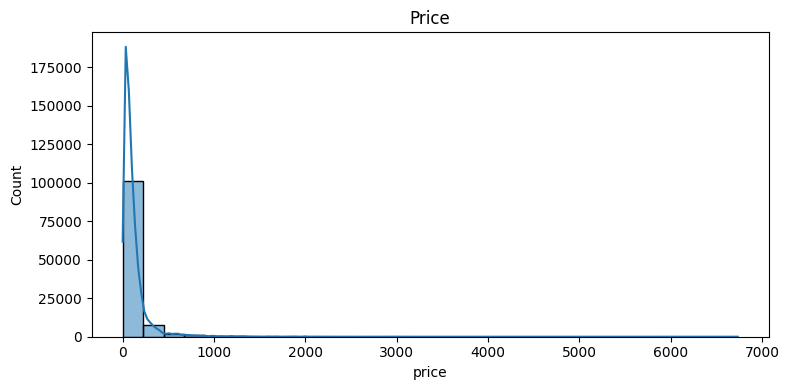

Saved → hist_payment_value.png


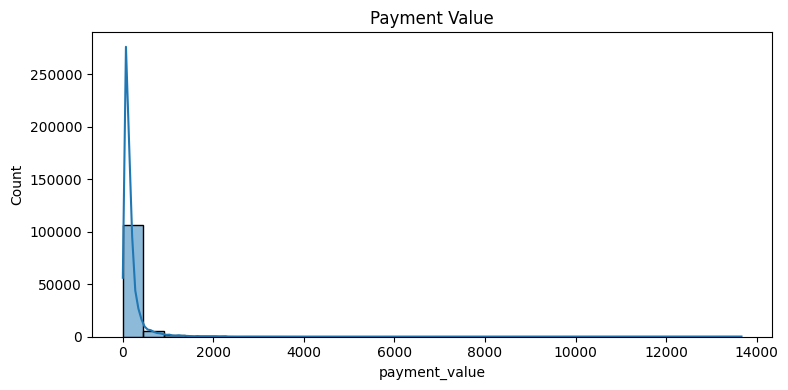

Saved → hist_freight_value.png


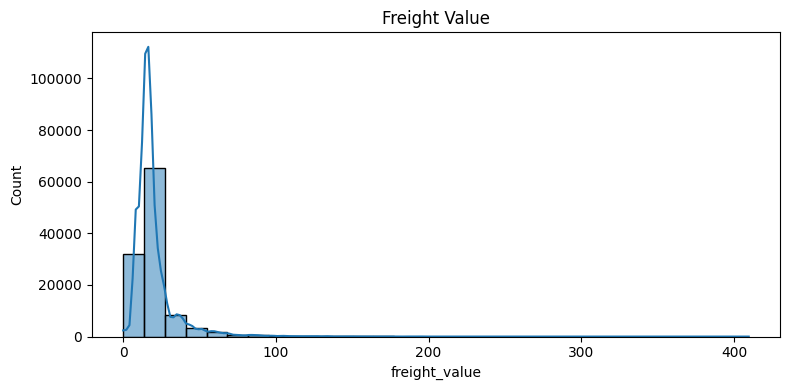

Saved → hist_review_score.png


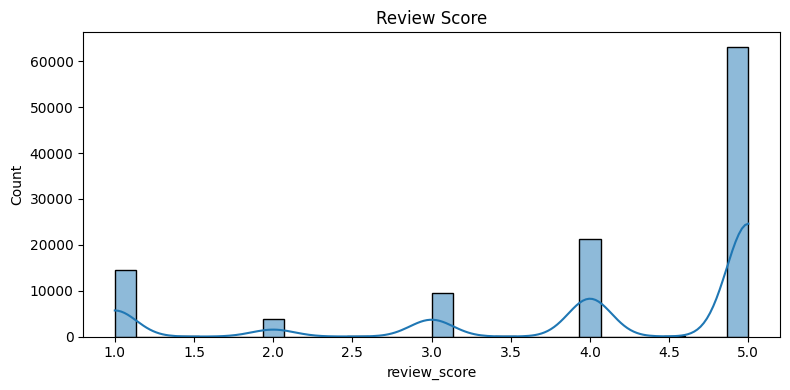

Saved → hist_approval_time_hours.png


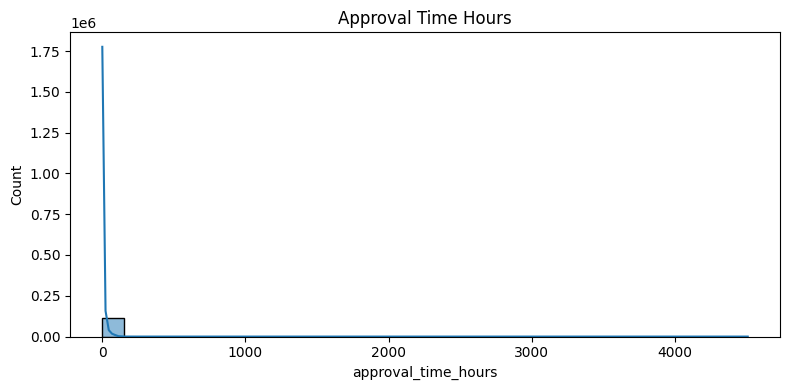

Saved → hist_delivery_time_days.png


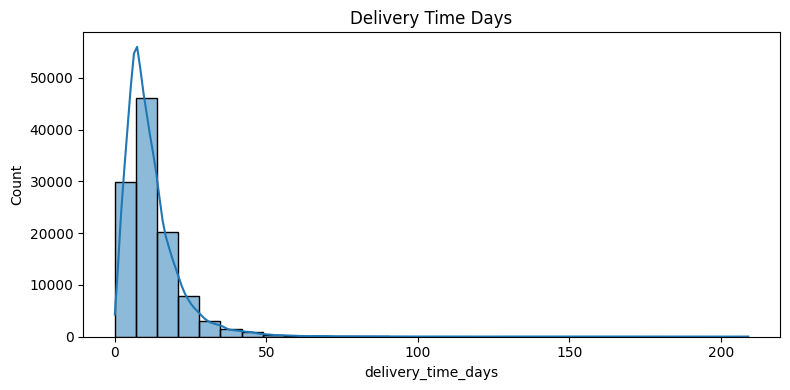

Saved → hist_shipping_time_days.png


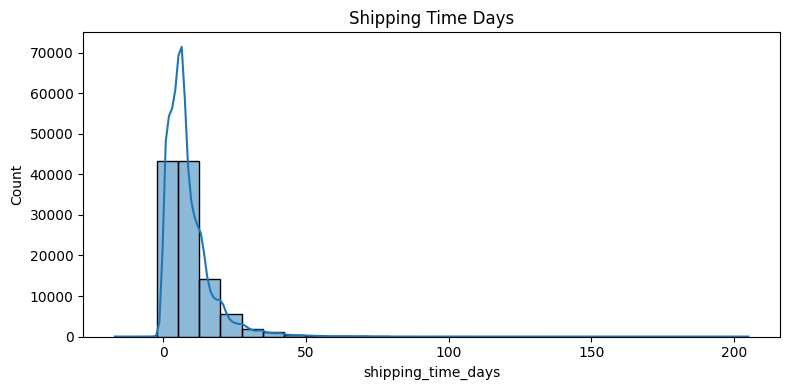

Saved → hist_delivery_delay_days.png


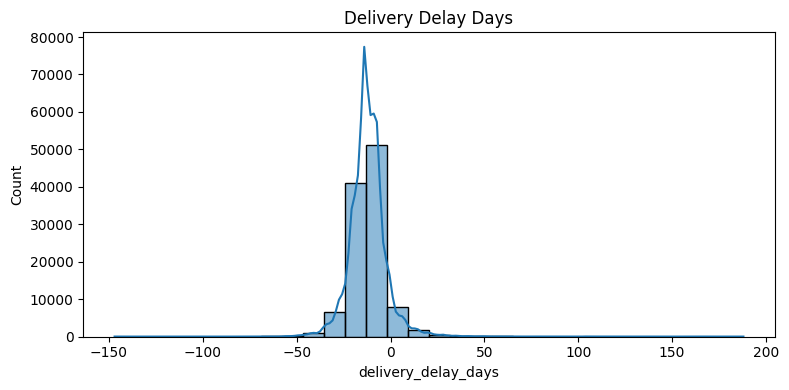

Saved → hist_payment_installments.png


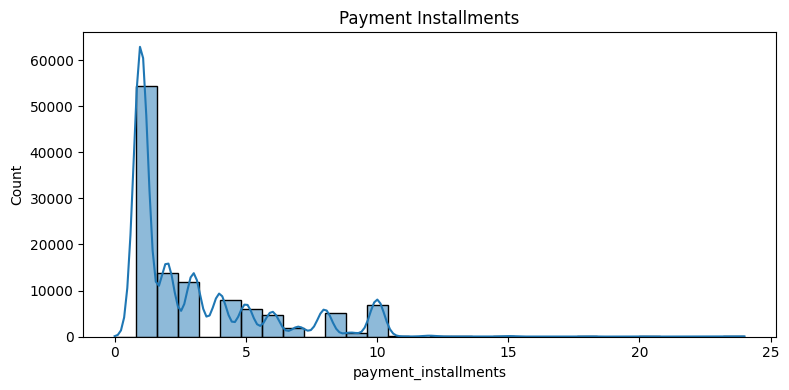

In [24]:
for column in business_numeric:

    plt.figure(figsize=(8,4))

    sns.histplot(
        sales_master[column],
        bins=30,
        kde=True
    )

    plt.title(column.replace("_"," ").title())

    save_plot(f"hist_{column}")

Saved → box_price.png


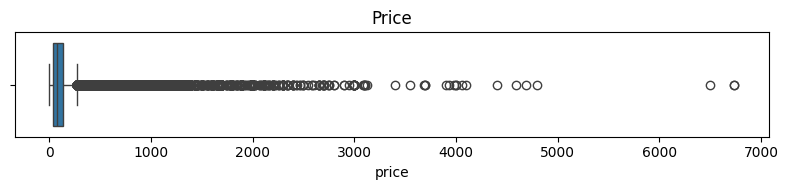

Saved → box_payment_value.png


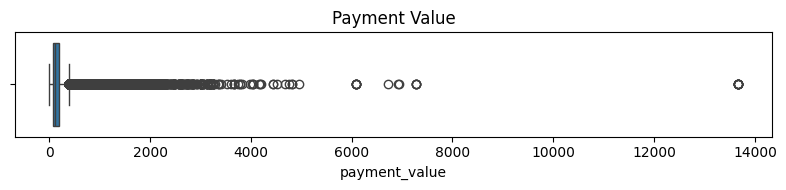

Saved → box_freight_value.png


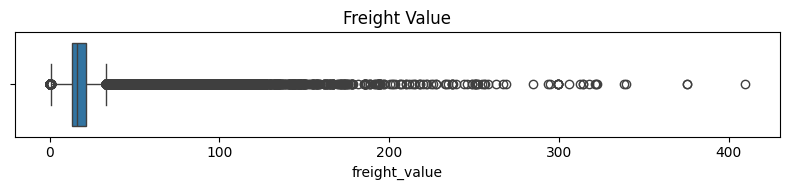

Saved → box_review_score.png


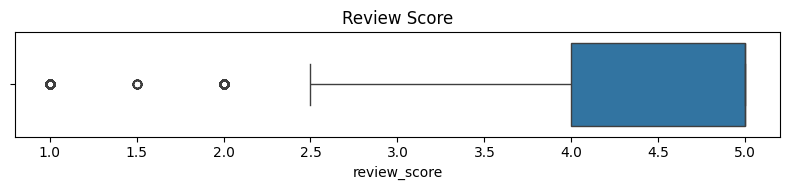

Saved → box_approval_time_hours.png


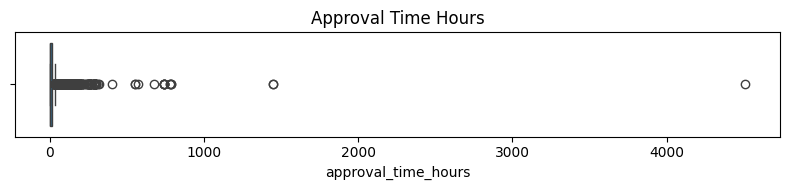

Saved → box_delivery_time_days.png


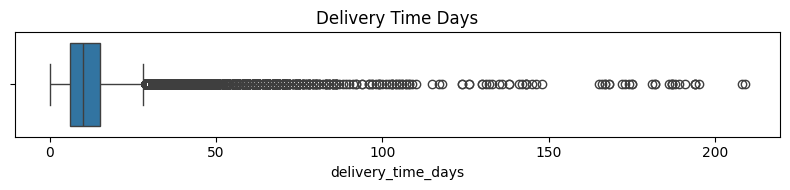

Saved → box_shipping_time_days.png


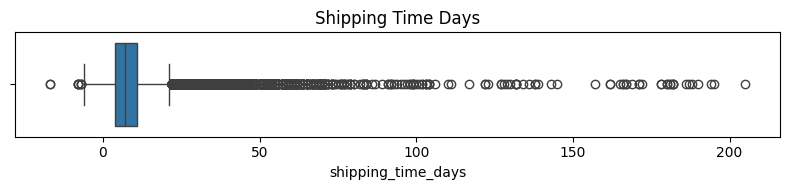

Saved → box_delivery_delay_days.png


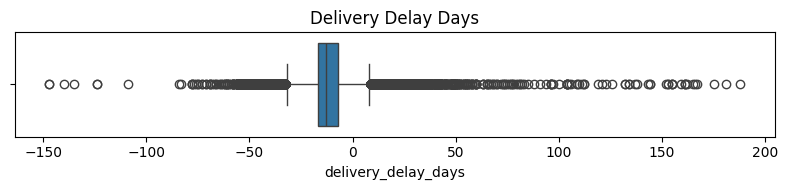

Saved → box_payment_installments.png


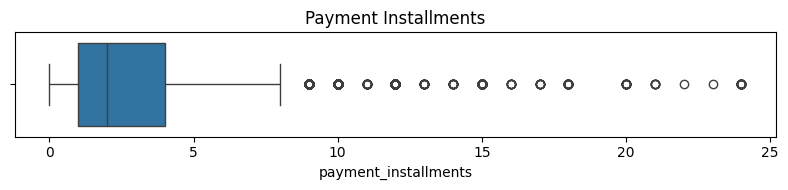

In [25]:
for column in business_numeric:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=sales_master[column]
    )

    plt.title(column.replace("_"," ").title())

    save_plot(f"box_{column}")

In [26]:
distribution_summary = (
    sales_master[business_numeric]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )
    .T
    .round(2)
)

distribution_summary

,count,mean,median,std,min,max
price,112650.0,120.65,74.99,183.63,0.85,6735.00
payment_value,113422.0,180.48,114.40,273.55,0.00,13664.08
freight_value,112650.0,19.99,16.26,15.81,0.00,409.68
review_score,112464.0,4.02,5.00,1.40,1.00,5.00
approval_time_hours,113264.0,10.66,0.35,26.23,0.00,4509.18
delivery_time_days,110196.0,12.01,10.00,9.45,0.00,209.00
shipping_time_days,110195.0,8.73,7.00,8.61,-17.00,205.00
delivery_delay_days,110196.0,-12.03,-13.00,10.16,-147.00,188.00
payment_installments,113422.0,3.02,2.00,2.80,0.00,24.00


In [27]:
print(f"Total Revenue : ${sales_master['price'].sum():,.2f}")

print(f"Average Order Value : ${sales_master['price'].mean():,.2f}")

print(f"Total Orders : {sales_master['order_id'].nunique():,}")

print(f"Total Customers : {sales_master['customer_unique_id'].nunique():,}")

Total Revenue : $13,591,643.70
Average Order Value : $120.65
Total Orders : 99,441
Total Customers : 96,096


In [28]:
monthly_sales = (
    sales_master
    .groupby(
        ["purchase_year","purchase_month"]
    )["price"]
    .sum()
    .reset_index()
)

monthly_sales["Year-Month"] = (
    monthly_sales["purchase_year"].astype(str)
    + "-"
    + monthly_sales["purchase_month"].astype(str).str.zfill(2)
)

monthly_sales.head()

,purchase_year,purchase_month,price,Year-Month
0,2016,9,267.36,2016-09
1,2016,10,49507.66,2016-10
2,2016,12,10.90,2016-12
3,2017,1,120312.87,2017-01
4,2017,2,247303.02,2017-02


Saved → 01_monthly_revenue_trend.png


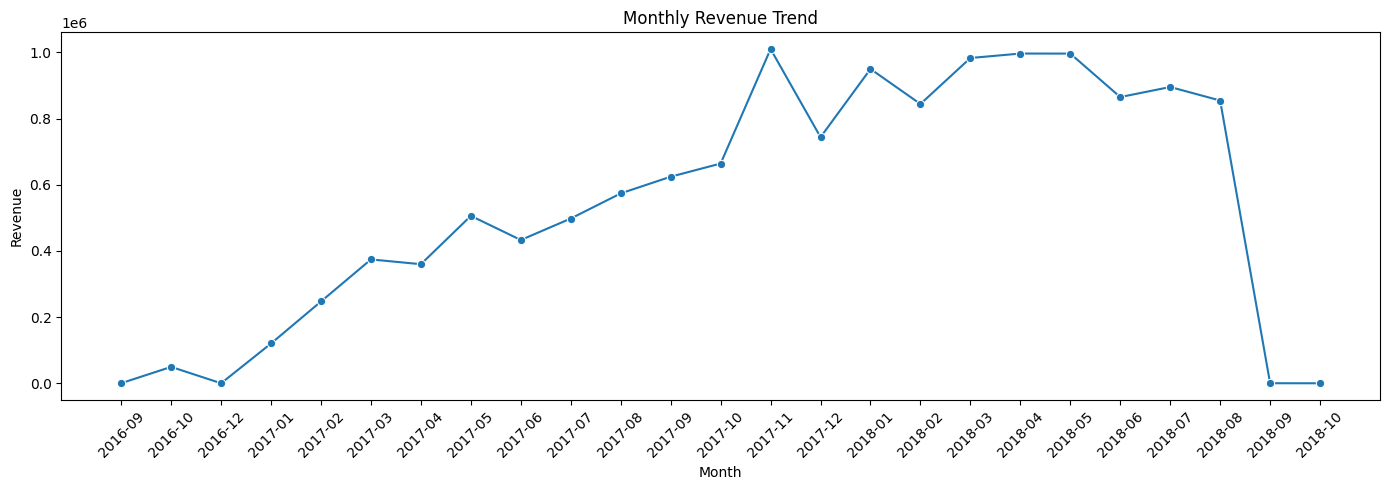

In [29]:
plt.figure(figsize=(14,5))

sns.lineplot(
    data=monthly_sales,
    x="Year-Month",
    y="price",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

save_plot("01_monthly_revenue_trend")

In [30]:
quarterly_sales = (
    sales_master
    .groupby("purchase_quarter")["price"]
    .sum()
    .reset_index()
)

quarterly_sales

,purchase_quarter,price
0,1,3519382.70
1,2,4157326.71
2,3,3447010.76
3,4,2467923.53


Saved → 02_revenue_by_quarter.png


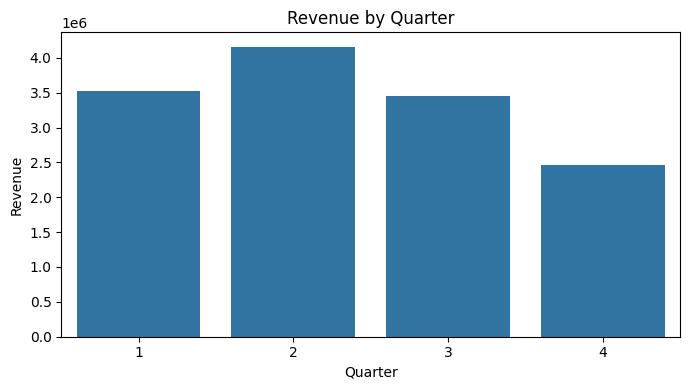

In [31]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=quarterly_sales,
    x="purchase_quarter",
    y="price"
)

plt.title("Revenue by Quarter")

plt.xlabel("Quarter")

plt.ylabel("Revenue")

save_plot("02_revenue_by_quarter")

In [32]:
weekday_sales = (
    sales_master
    .groupby("purchase_weekday")["price"]
    .sum()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index()
)

weekday_sales

,purchase_weekday,price
0,Monday,2230812.51
1,Tuesday,2172647.82
2,Wednesday,2113843.59
3,Thursday,2018615.78
4,Friday,1962426.75
5,Saturday,1504018.36
6,Sunday,1589278.89


Saved → 03_revenue_by_weekday.png


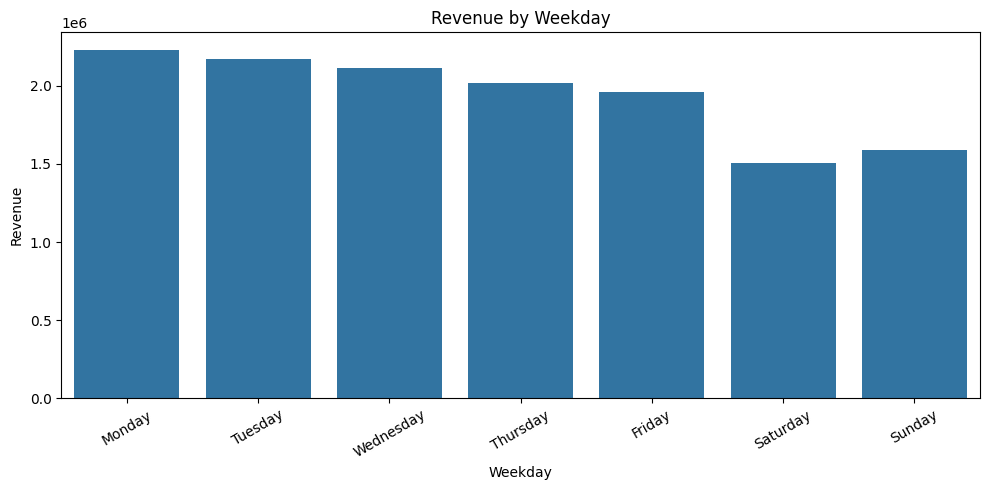

In [33]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=weekday_sales,
    x="purchase_weekday",
    y="price"
)

plt.xticks(rotation=30)

plt.title("Revenue by Weekday")

plt.xlabel("Weekday")

plt.ylabel("Revenue")

save_plot("03_revenue_by_weekday")

In [34]:
hourly_sales = (
    sales_master
    .groupby("purchase_hour")["price"]
    .sum()
    .reset_index()
)

hourly_sales.head()

,purchase_hour,price
0,0,316817.97
1,1,150011.92
2,2,54833.01
3,3,35525.11
4,4,24281.59


Saved → 04_revenue_by_hour.png


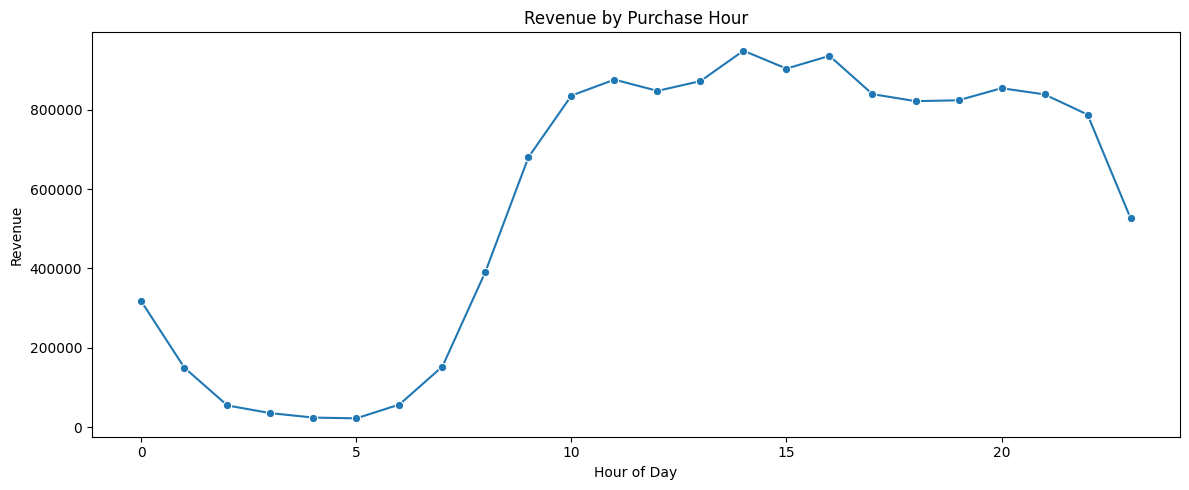

In [35]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=hourly_sales,
    x="purchase_hour",
    y="price",
    marker="o"
)

plt.title("Revenue by Purchase Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")

save_plot("04_revenue_by_hour")

In [36]:
state_sales = (
    sales_master
    .groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

state_sales

,customer_state,price
0,SP,5202955.05
1,RJ,1824092.67
2,MG,1585308.03
3,RS,750304.02
4,PR,683083.76
5,SC,520553.34
6,BA,511349.99
7,DF,302603.94
8,GO,294591.95
9,ES,275037.31


Saved → 05_revenue_by_state.png


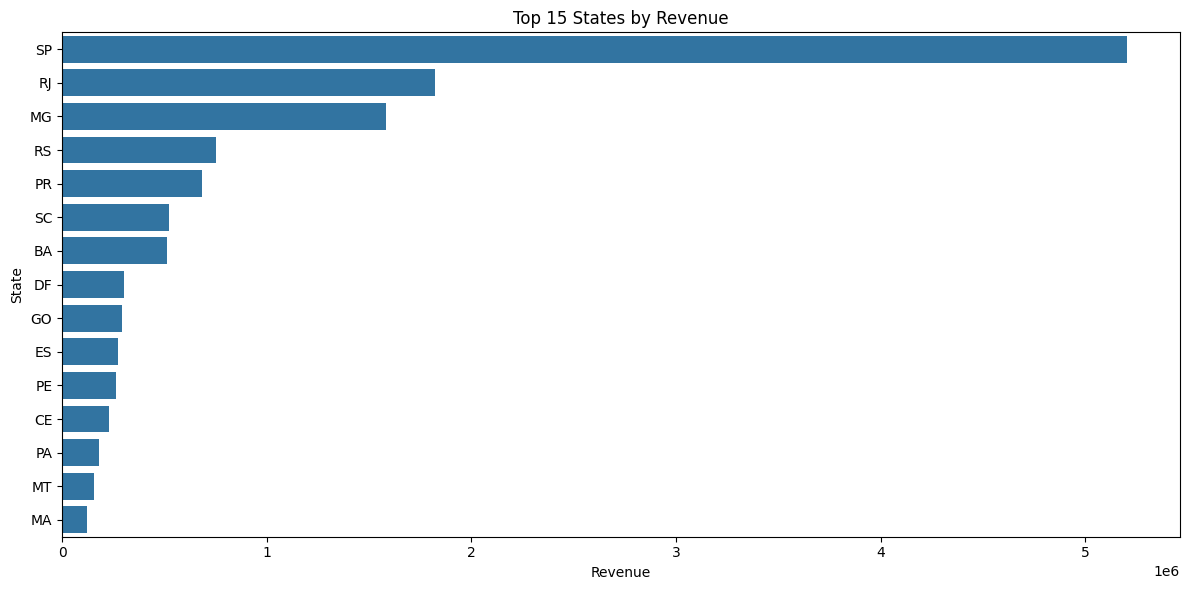

In [37]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=state_sales,
    x="price",
    y="customer_state"
)

plt.title("Top 15 States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("State")

save_plot("05_revenue_by_state")

In [38]:
category_sales = (
    sales_master
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

category_sales

,product_category_name,price
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


Saved → 06_product_category_revenue.png


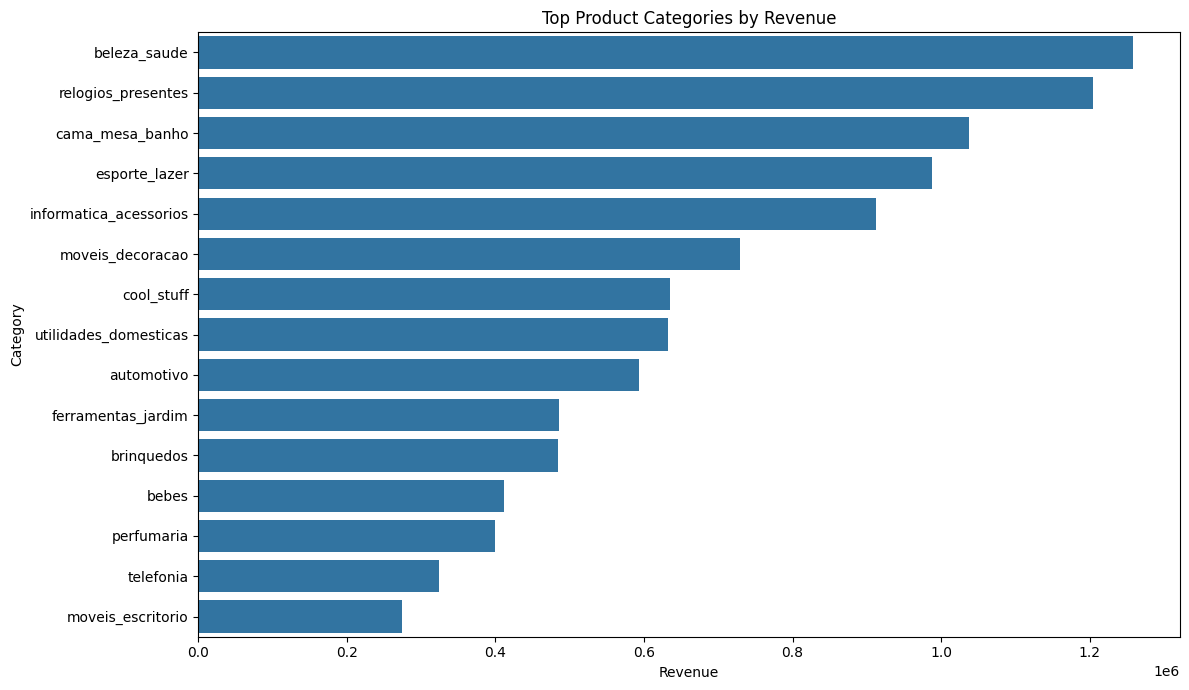

In [39]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=category_sales,
    x="price",
    y="product_category_name"
)

plt.title("Top Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")

save_plot("06_product_category_revenue")

In [40]:
seller_sales = (
    sales_master
    .groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

seller_sales

,seller_id,price
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63
1,53243585a1d6dc2643021fd1853d8905,222776.05
2,4a3ca9315b744ce9f8e9374361493884,200472.92
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03
4,7c67e1448b00f6e969d365cea6b010ab,187923.89
5,7e93a43ef30c4f03f38b393420bc753a,176431.87
6,da8622b14eb17ae2831f4ac5b9dab84a,160236.57
7,7a67c85e85bb2ce8582c35f2203ad736,141745.53
8,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55
9,955fee9216a65b617aa5c0531780ce60,135171.70


Saved → 07_top_sellers.png


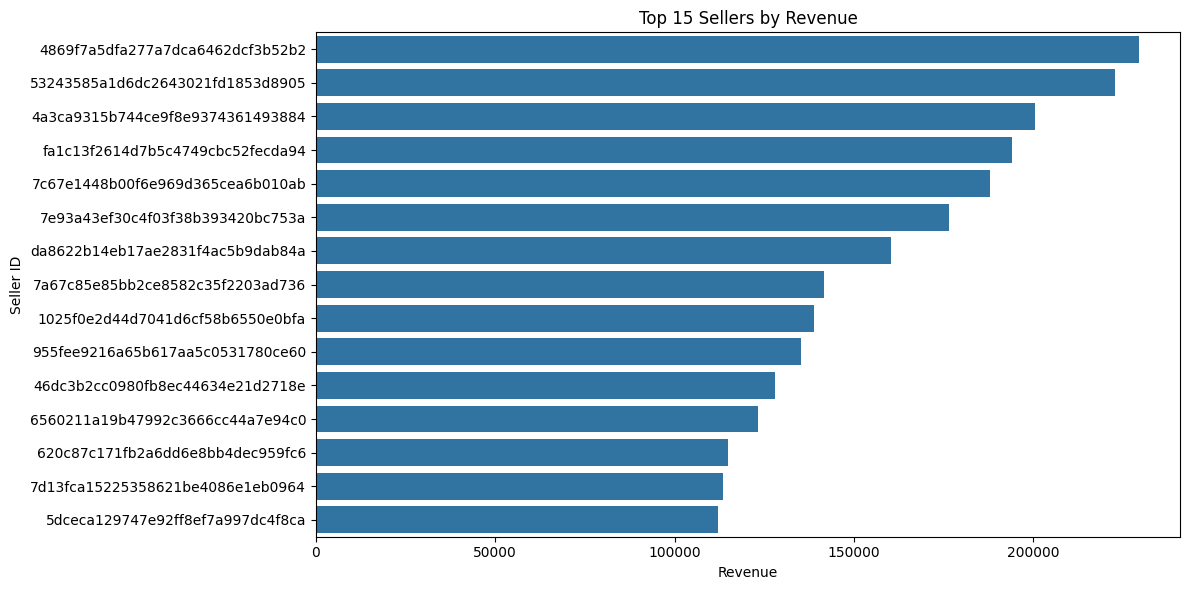

In [41]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=seller_sales,
    x="price",
    y="seller_id"
)

plt.title("Top 15 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller ID")

save_plot("07_top_sellers")

In [42]:
payment_summary = (
    sales_master["payment_type"]
    .value_counts()
    .reset_index()
)

payment_summary.columns = [
    "payment_type",
    "count"
]

payment_summary

,payment_type,count
0,credit_card,86526
1,boleto,23037
2,voucher,2160
3,debit_card,1696
4,not_defined,3


Saved → 08_payment_methods.png


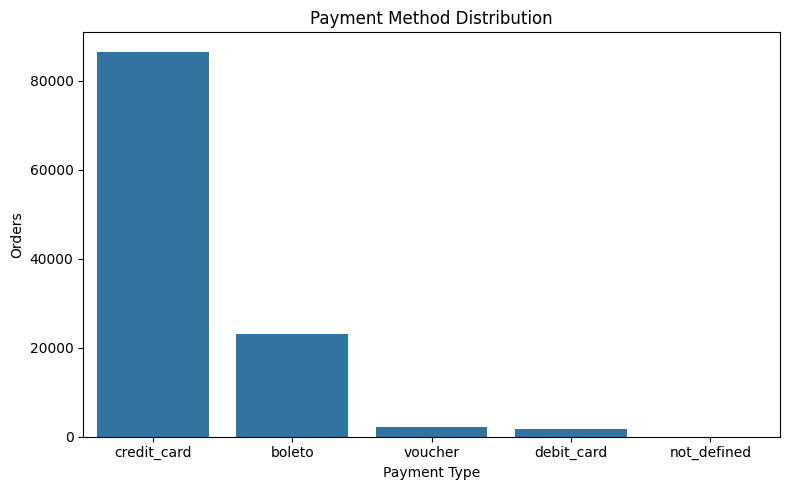

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=payment_summary,
    x="payment_type",
    y="count"
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Orders")

save_plot("08_payment_methods")

In [44]:
order_status = (
    sales_master["order_status"]
    .value_counts()
    .reset_index()
)

order_status.columns = [
    "order_status",
    "count"
]

order_status

,order_status,count
0,delivered,110197
1,shipped,1186
2,canceled,706
3,unavailable,610
4,invoiced,361
5,processing,357
6,created,5
7,approved,3


Saved → 09_order_status_distribution.png


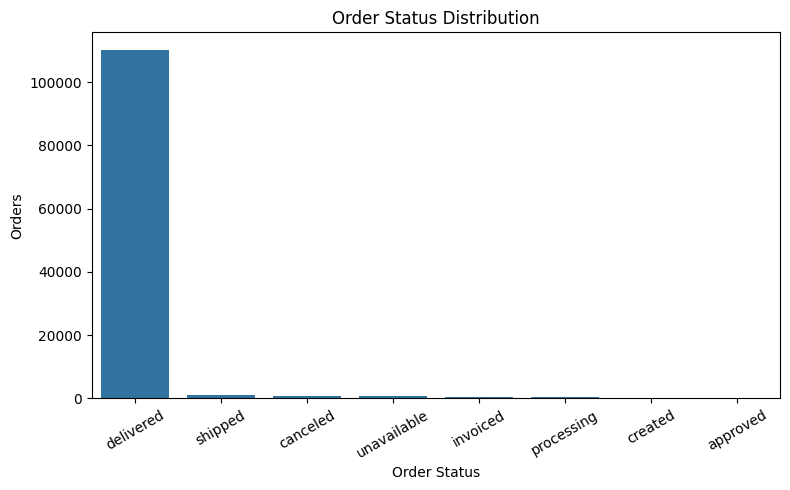

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=order_status,
    x="order_status",
    y="count"
)

plt.xticks(rotation=30)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Orders")

save_plot("09_order_status_distribution")

In [46]:
print(f"Unique Customers : {sales_master['customer_unique_id'].nunique():,}")

print(f"Average Order Value : ${sales_master['price'].mean():,.2f}")

print(f"Average Review Score : {sales_master['review_score'].mean():.2f}")

Unique Customers : 96,096
Average Order Value : $120.65
Average Review Score : 4.02


In [47]:
customer_orders = (
    sales_master
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="orders")
)

customer_orders.head()

,customer_unique_id,orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


Saved → 10_orders_per_customer.png


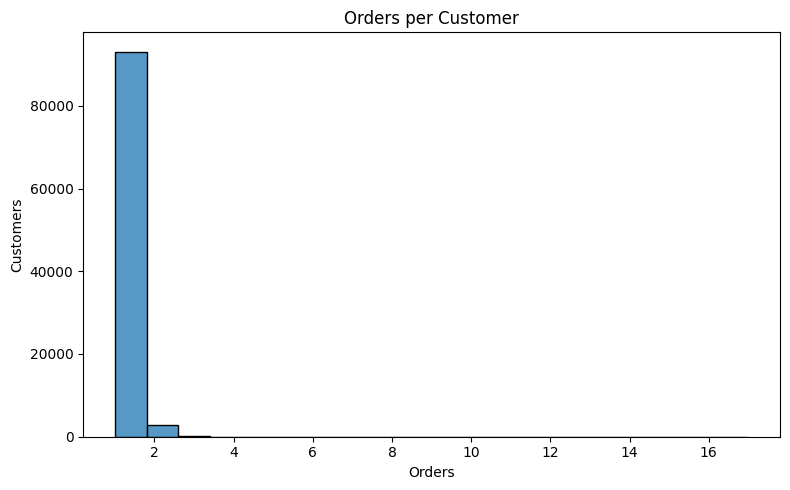

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_orders["orders"],
    bins=20
)

plt.title("Orders per Customer")

plt.xlabel("Orders")

plt.ylabel("Customers")

save_plot("10_orders_per_customer")

In [49]:
repeat_customers = (
    customer_orders["orders"] > 1
).sum()

one_time_customers = (
    customer_orders["orders"] == 1
).sum()

customer_type = pd.DataFrame({
    "Customer Type":[
        "One-Time",
        "Repeat"
    ],
    "Count":[
        one_time_customers,
        repeat_customers
    ]
})

customer_type

,Customer Type,Count
0,One-Time,93099
1,Repeat,2997


Saved → 11_repeat_customers.png


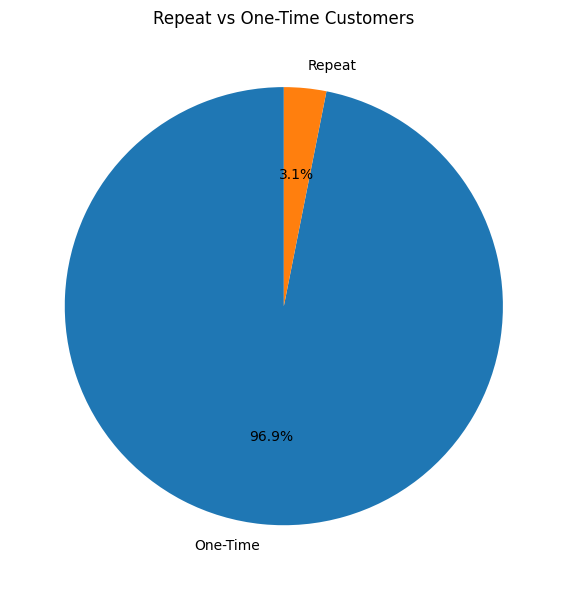

In [50]:
plt.figure(figsize=(6,6))

plt.pie(
    customer_type["Count"],
    labels=customer_type["Customer Type"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Repeat vs One-Time Customers")

save_plot("11_repeat_customers")

In [51]:
customer_state_value = (
    sales_master
    .groupby("customer_state")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

customer_state_value

,customer_state,price
0,PB,191.475216
1,AL,180.889212
2,AC,173.727717
3,RO,165.973525
4,PA,165.692417
5,AP,164.320732
6,PI,160.358081
7,TO,157.529333
8,RN,156.965936
9,CE,153.758261


Saved → 12_customer_spend_by_state.png


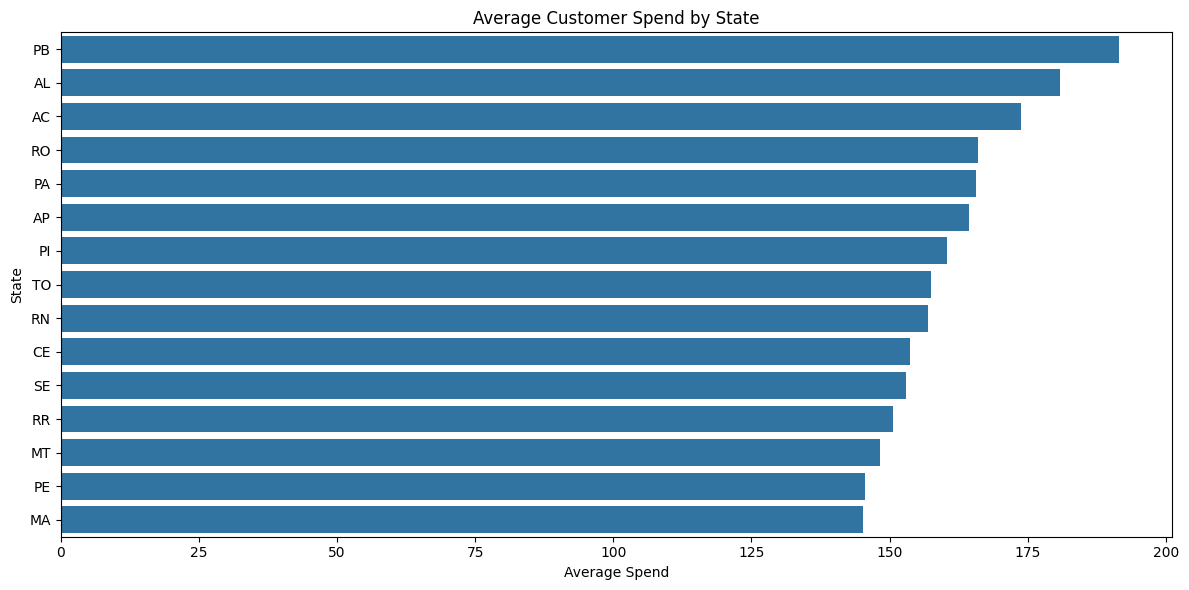

In [52]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=customer_state_value,
    x="price",
    y="customer_state"
)

plt.title("Average Customer Spend by State")

plt.xlabel("Average Spend")

plt.ylabel("State")

save_plot("12_customer_spend_by_state")

In [53]:
review_distribution = (
    sales_master["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

review_distribution.columns = [
    "Review Score",
    "Count"
]

review_distribution

,Review Score,Count
0,1.000000,14617
1,1.500000,18
2,2.000000,3895
3,2.500000,46
4,3.000000,9437
5,3.333333,1
6,3.500000,31
7,4.000000,21198
8,4.333333,1
9,4.500000,68


Saved → 13_review_distribution.png


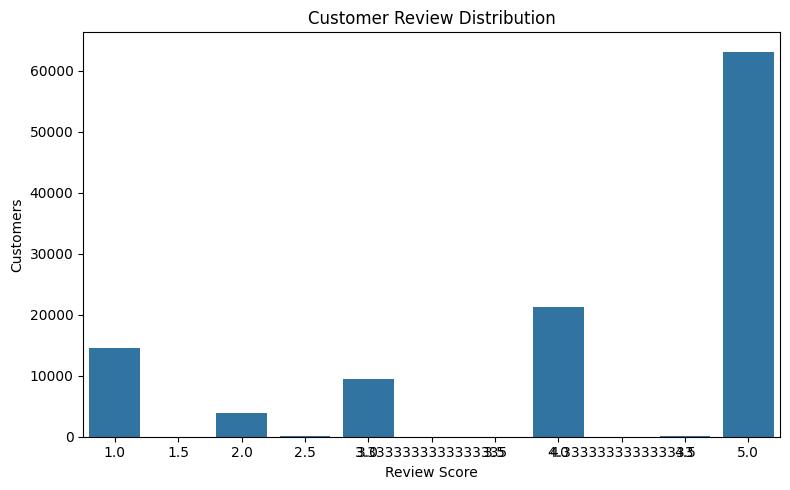

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=review_distribution,
    x="Review Score",
    y="Count"
)

plt.title("Customer Review Distribution")

plt.xlabel("Review Score")

plt.ylabel("Customers")

save_plot("13_review_distribution")

In [55]:


top_products = (
    sales_master
    .groupby("product_category_name")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="orders")
)

top_products

,product_category_name,orders
0,cama_mesa_banho,11115
1,beleza_saude,9670
2,esporte_lazer,8641
3,moveis_decoracao,8334
4,informatica_acessorios,7827
5,utilidades_domesticas,6964
6,relogios_presentes,5991
7,telefonia,4545
8,ferramentas_jardim,4347
9,automotivo,4235


Saved → 14_top_products_orders.png


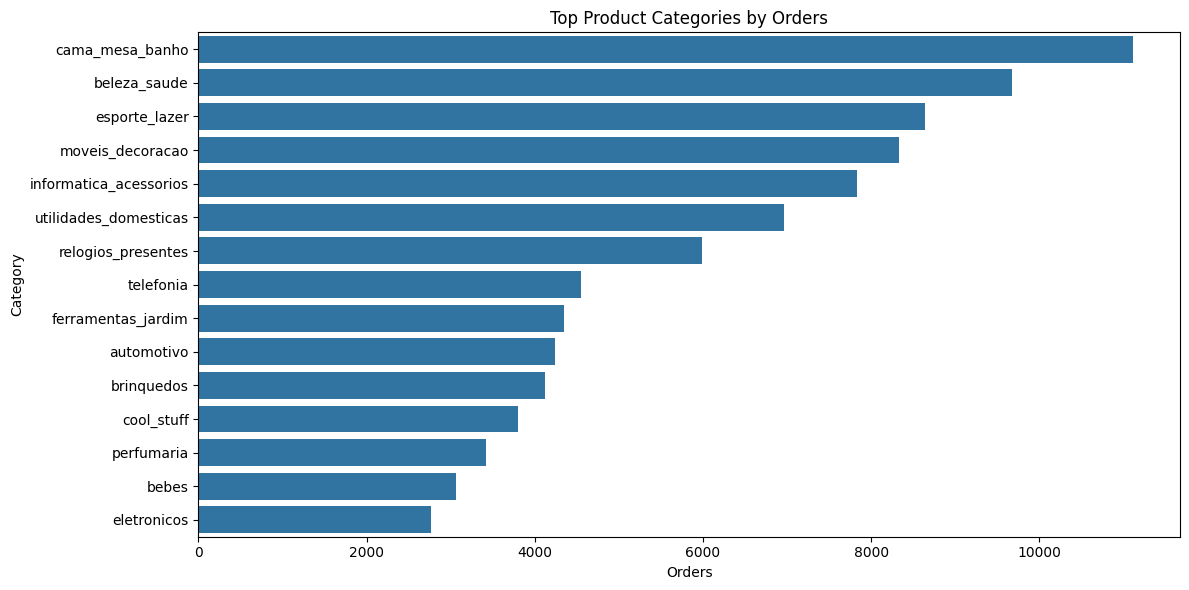

In [56]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_products,
    x="orders",
    y="product_category_name"
)

plt.title("Top Product Categories by Orders")

plt.xlabel("Orders")

plt.ylabel("Category")

save_plot("14_top_products_orders")

In [57]:
avg_product_price = (
    sales_master
    .groupby("product_category_name")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

avg_product_price

,product_category_name,price
0,pcs,1098.340542
1,portateis_casa_forno_e_cafe,624.285658
2,eletrodomesticos_2,476.124958
3,agro_industria_e_comercio,342.124858
4,instrumentos_musicais,281.616000
5,eletroportateis,280.778468
6,portateis_cozinha_e_preparadores_de_alimentos,264.568667
7,telefonia_fixa,225.693182
8,construcao_ferramentas_seguranca,208.992371
9,relogios_presentes,201.135984


Saved → 15_average_product_price.png


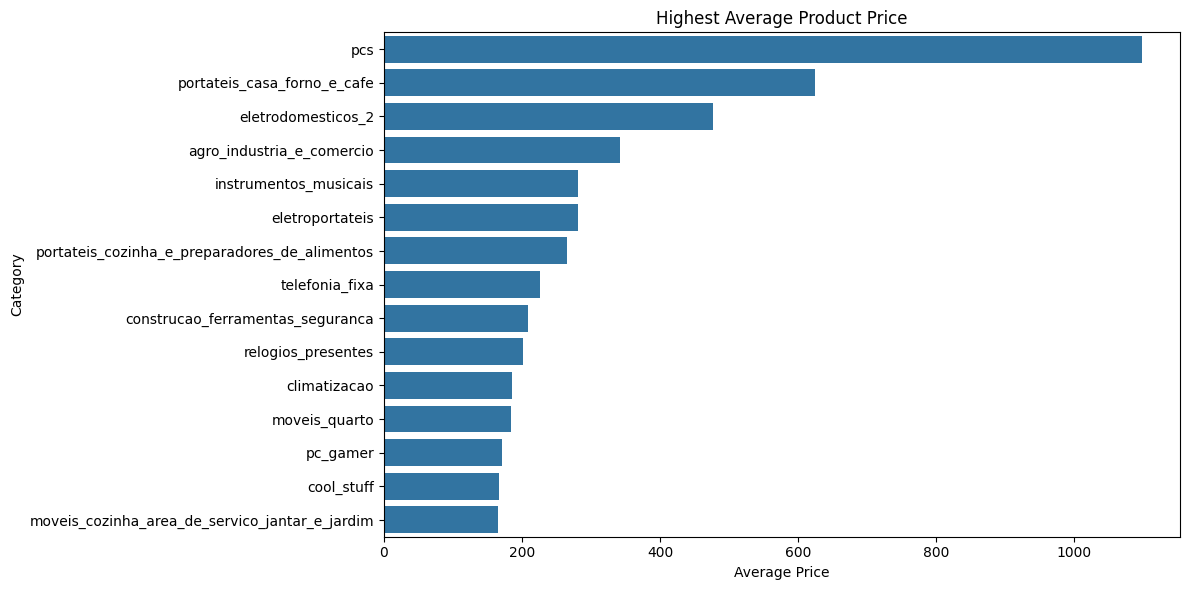

In [58]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=avg_product_price,
    x="price",
    y="product_category_name"
)

plt.title("Highest Average Product Price")

plt.xlabel("Average Price")

plt.ylabel("Category")

save_plot("15_average_product_price")

In [59]:
seller_orders = (
    sales_master
    .groupby("seller_id")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="orders")
)

seller_orders

,seller_id,orders
0,6560211a19b47992c3666cc44a7e94c0,2033
1,4a3ca9315b744ce9f8e9374361493884,1987
2,1f50f920176fa81dab994f9023523100,1931
3,cc419e0650a3c5ba77189a1882b7556a,1775
4,da8622b14eb17ae2831f4ac5b9dab84a,1551
5,955fee9216a65b617aa5c0531780ce60,1499
6,1025f0e2d44d7041d6cf58b6550e0bfa,1428
7,7c67e1448b00f6e969d365cea6b010ab,1364
8,ea8482cd71df3c1969d7b9473ff13abc,1203
9,7a67c85e85bb2ce8582c35f2203ad736,1171


Saved → 16_top_sellers_orders.png


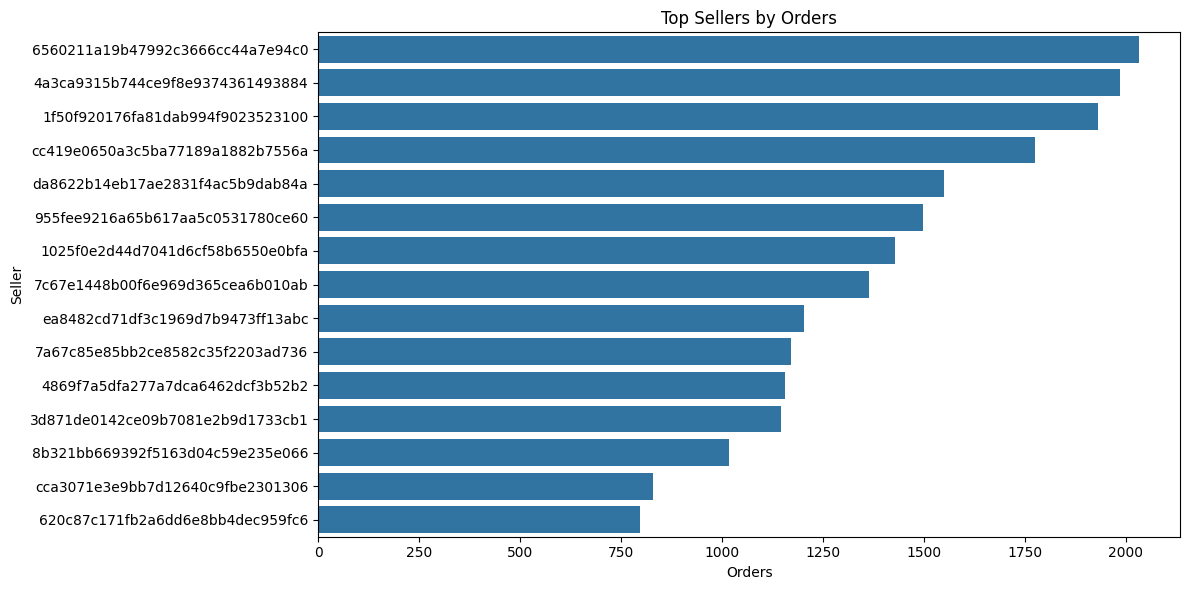

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=seller_orders,
    x="orders",
    y="seller_id"
)

plt.title("Top Sellers by Orders")

plt.xlabel("Orders")

plt.ylabel("Seller")

save_plot("16_top_sellers_orders")

In [61]:
sales_master["freight_percentage"] = (
    sales_master["freight_value"]
    / sales_master["price"]
) * 100

sales_master["freight_percentage"].describe()

count    112650.000000
mean         32.086355
std          34.989368
min           0.000000
25%          13.403366
50%          23.135624
75%          39.303621
max        2623.529412
Name: freight_percentage, dtype: float64

Saved → 17_freight_percentage.png


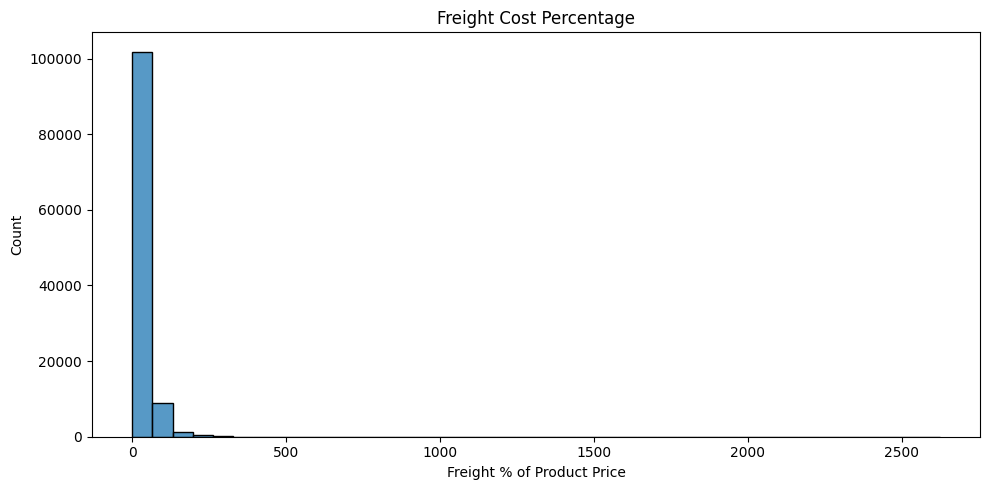

In [62]:
plt.figure(figsize=(10,5))

sns.histplot(
    sales_master["freight_percentage"],
    bins=40
)

plt.title("Freight Cost Percentage")

plt.xlabel("Freight % of Product Price")

save_plot("17_freight_percentage")

In [70]:
delivery_status = (
    sales_master
    .groupby("order_status")["delivery_time_days"]
    .mean()
    .sort_values()
    .reset_index()
)

delivery_status

,order_status,delivery_time_days
0,delivered,12.007342
1,canceled,18.000000
2,approved,NaN
3,created,NaN
4,invoiced,NaN
5,processing,NaN
6,shipped,NaN
7,unavailable,NaN


Saved → 18_delivery_time_by_status.png


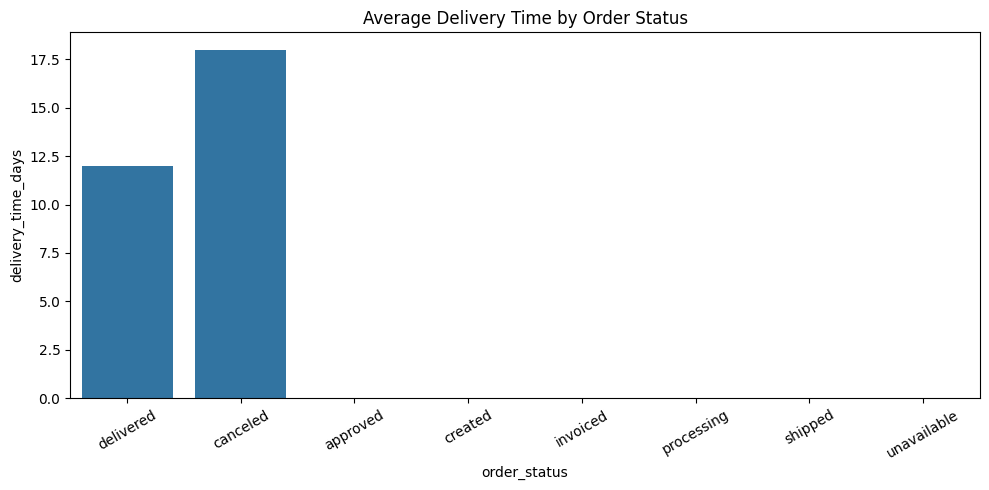

In [71]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=delivery_status,
    x="order_status",
    y="delivery_time_days"
)

plt.xticks(rotation=30)

plt.title("Average Delivery Time by Order Status")

save_plot("18_delivery_time_by_status")

In [72]:
review_delay = (
    sales_master
    .groupby("review_score")["delivery_delay_days"]
    .mean()
    .reset_index()
)

review_delay

,review_score,delivery_delay_days
0,1.000000,-5.927227
1,1.500000,-9.166667
2,2.000000,-9.720492
3,2.500000,-10.390244
4,3.000000,-11.088034
5,3.333333,-14.000000
6,3.500000,-14.379310
7,4.000000,-12.478422
8,4.333333,-11.000000
9,4.500000,-12.656716


Saved → 19_review_vs_delay.png


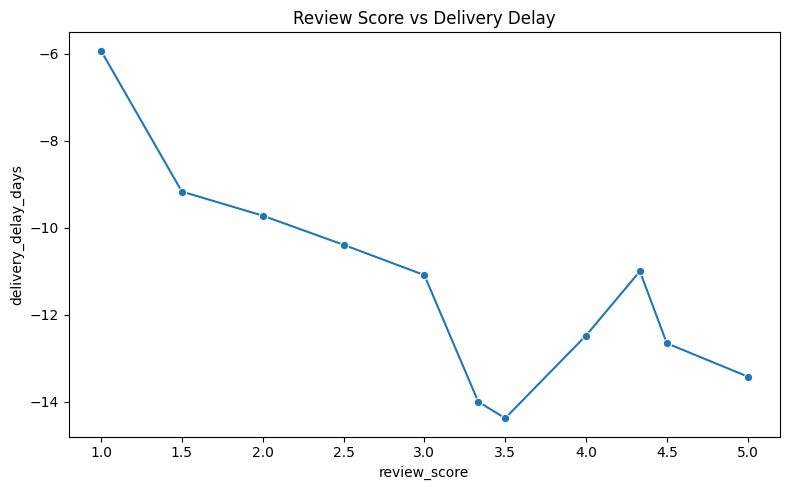

In [73]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=review_delay,
    x="review_score",
    y="delivery_delay_days",
    marker="o"
)

plt.title("Review Score vs Delivery Delay")

save_plot("19_review_vs_delay")

In [74]:
corr_columns = [
    "price",
    "payment_value",
    "freight_value",
    "delivery_time_days",
    "shipping_time_days",
    "approval_time_hours",
    "delivery_delay_days",
    "review_score"
]

sales_master[corr_columns].corr()

,price,payment_value,freight_value,delivery_time_days,shipping_time_days,approval_time_hours,delivery_delay_days,review_score
price,1.000000,0.761235,0.414204,0.062290,0.041351,0.014374,-0.003596,-0.004081
payment_value,0.761235,1.000000,0.386453,0.063018,0.028273,0.043671,-0.020800,-0.084756
freight_value,0.414204,0.386453,1.000000,0.214631,0.196935,0.031414,-0.040242,-0.036363
delivery_time_days,0.062290,0.063018,0.214631,1.000000,0.920827,0.084426,0.597315,-0.304867
shipping_time_days,0.041351,0.028273,0.196935,0.920827,1.000000,0.008125,0.569063,-0.267997
approval_time_hours,0.014374,0.043671,0.031414,0.084426,0.008125,1.000000,0.042352,-0.027332
delivery_delay_days,-0.003596,-0.020800,-0.040242,0.597315,0.569063,0.042352,1.000000,-0.229265
review_score,-0.004081,-0.084756,-0.036363,-0.304867,-0.267997,-0.027332,-0.229265,1.000000


Saved → 20_correlation_heatmap.png


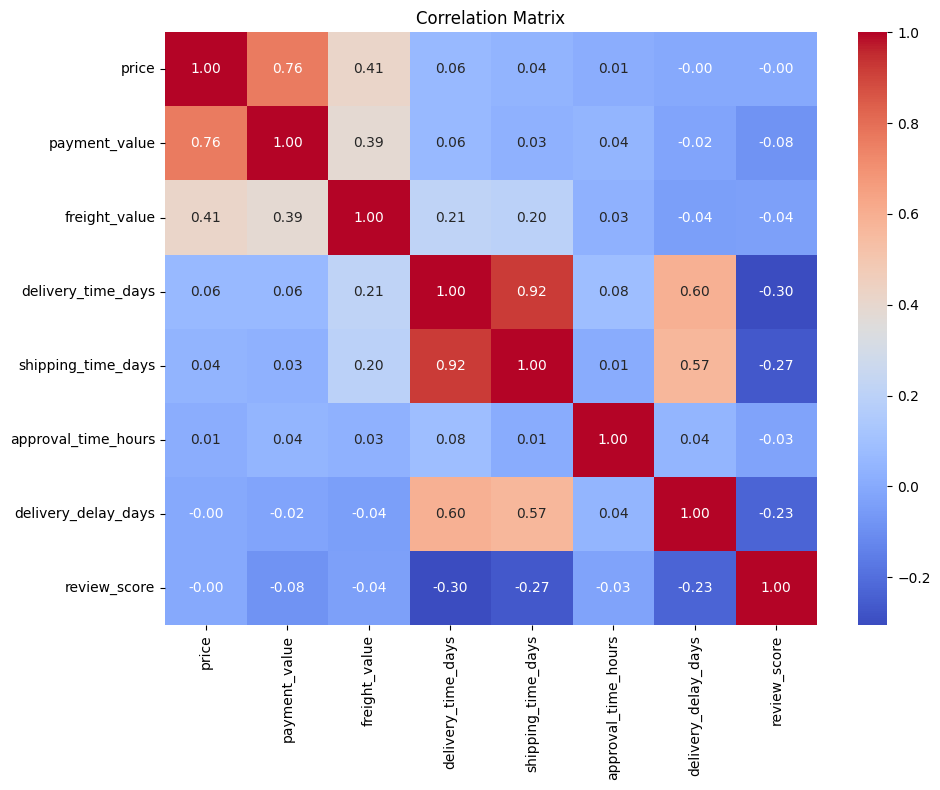

In [75]:
plt.figure(figsize=(10,8))

sns.heatmap(
    sales_master[corr_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

save_plot("20_correlation_heatmap")